<a href="https://colab.research.google.com/github/amenasadiq7/MATH572/blob/main/Homework_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pylab inline
%config InlineBackend.figure_format = 'retina'
from ipywidgets import interact
import scipy.stats as stats
import pandas as pd
import pymc as pm
import arviz as az

Populating the interactive namespace from numpy and matplotlib


In [2]:
path_to_data = 'https://raw.githubusercontent.com/ccontrer/MATH509-Winter2025-JupyterNotebooks/main/Data/'
data = pd.read_csv(path_to_data + 'WaffleDivorce.csv', sep=";", header=0)

# Q1
It is sometimes observed that the best predictor of fire risk is the presence of firefighters—States and localities with many firefighters also have more fires. Presumably firefighters do not cause fires. Nevertheless, this is not a spurious correlation. Instead fires cause firefighters. Consider the same reversal of causal inference in the context of the divorce and marriage data. How might a high divorce rate cause a higher marriage rate? Can you think of a way to evaluate this relationship using multiple regression?

A high divorce rate could increase the number of individuals available for remarriage, potentially leading to higher marriage rates. Multiple regression analysis could be performed, evaluating marriage rates in with both divorce rates and remarriage rates. While multiple regression can help identify correlations and control for confounding variables, it does not establish causation. Therefore, additional methods, such as instrumental variable analysis or longitudinal studies, may be needed to explore the causal relationship between divorce and marriage rates.

# Q2
In the divorce data, States with high numbers of Mormons (members of The Church of Jesus Christ of Latter-day Saints, LDS) have much lower divorce rates than the regression models expected. Find a list [here](https://en.wikipedia.org/wiki/The_Church_of_Jesus_Christ_of_Latter-day_Saints_membership_statistics_(United_States)) of LDS population by State and use those numbers as a predictor variable, predicting divorce rate using marriage rate, median age at marriage, and percent LDS population (possibly standardized). You may want to consider transformations of the raw percent LDS variable.

In [3]:
print(data)

                Location Loc  Population  MedianAgeMarriage  Marriage  \
0                Alabama  AL        4.78               25.3      20.2   
1                 Alaska  AK        0.71               25.2      26.0   
2                Arizona  AZ        6.33               25.8      20.3   
3               Arkansas  AR        2.92               24.3      26.4   
4             California  CA       37.25               26.8      19.1   
5               Colorado  CO        5.03               25.7      23.5   
6            Connecticut  CT        3.57               27.6      17.1   
7               Delaware  DE        0.90               26.6      23.1   
8   District of Columbia  DC        0.60               29.7      17.7   
9                Florida  FL       18.80               26.4      17.0   
10               Georgia  GA        9.69               25.9      22.1   
11                Hawaii  HI        1.36               26.9      24.9   
12                 Idaho  ID        1.57           

In [4]:
# state names and %LDS values
lds = [
    ("Alabama", 0.78), ("Alaska", 4.58), ("Arizona", 5.97), ("Arkansas", 1.16), ("California", 1.87),
    ("Colorado", 2.55), ("Connecticut", 0.44), ("Delaware", 0.55), ("District of Columbia", 0.47), ("Florida", 0.76),
    ("Georgia", 0.82), ("Hawaii", 5.20), ("Idaho", 24.44), ("Illinois", 0.45), ("Indiana", 0.69),
    ("Iowa", 0.90), ("Kansas", 1.34), ("Kentucky", 0.84), ("Louisiana", 0.65), ("Maine", 0.80),
    ("Maryland", 0.70), ("Massachusetts", 0.40), ("Michigan", 0.45), ("Minnesota", 0.58), ("Mississippi", 0.75),
    ("Missouri", 1.26), ("Montana", 4.61), ("Nebraska", 1.28), ("Nevada", 5.73), ("New Hampshire", 0.64),
    ("New Jersey", 0.37), ("New Mexico", 3.27), ("New York", 0.43), ("North Carolina", 0.88), ("North Dakota", 1.47),
    ("Ohio", 0.54), ("Oklahoma", 1.29), ("Oregon", 3.54), ("Pennsylvania", 0.40), ("Rhode Island", 0.40),
    ("South Carolina", 0.84), ("South Dakota", 1.26), ("Tennessee", 0.81), ("Texas", 1.26), ("Utah", 64.29),
    ("Vermont", 0.72), ("Virginia", 1.12), ("Washington", 3.61), ("West Virginia", 0.97), ("Wisconsin", 0.47),
    ("Wyoming", 11.66)
]

lds_df = pd.DataFrame(lds, columns=["State", "LDS"])

# Merging the lds_df DataFrame with the waffle DataFrame based on the state names
waffle = pd.merge(data, lds_df, how="left", left_on="Location", right_on="State")

print(waffle)

                Location Loc  Population  MedianAgeMarriage  Marriage  \
0                Alabama  AL        4.78               25.3      20.2   
1                 Alaska  AK        0.71               25.2      26.0   
2                Arizona  AZ        6.33               25.8      20.3   
3               Arkansas  AR        2.92               24.3      26.4   
4             California  CA       37.25               26.8      19.1   
5               Colorado  CO        5.03               25.7      23.5   
6            Connecticut  CT        3.57               27.6      17.1   
7               Delaware  DE        0.90               26.6      23.1   
8   District of Columbia  DC        0.60               29.7      17.7   
9                Florida  FL       18.80               26.4      17.0   
10               Georgia  GA        9.69               25.9      22.1   
11                Hawaii  HI        1.36               26.9      24.9   
12                 Idaho  ID        1.57           

In [5]:
# Standardizing Predictors
age = (waffle['MedianAgeMarriage'].values - np.mean(waffle['MedianAgeMarriage'].values)) / np.std(waffle['MedianAgeMarriage'].values)
marriage = (waffle['Marriage'].values - np.mean(waffle['Marriage'].values)) / np.std(waffle['Marriage'].values)
LDS = np.log(waffle['LDS'])
LDS = (waffle['LDS'].values - np.mean(waffle['LDS'].values)) / np.std(waffle['LDS'].values)

In [6]:
# PyMC model
np.random.seed(106)
with pm.Model() as linreg:
    alpha = pm.Normal("alpha", mu=0, sigma=20)
    beta_M = pm.Normal("beta_M", mu=0, sigma=10)
    beta_A = pm.Normal("beta_A", mu=0, sigma=10)
    beta_L = pm.Normal("beta_L", mu=0, sigma=10)
    sigma = pm.Uniform("sigma", lower=0, upper=5)

    mu = alpha + beta_M * marriage + beta_A * age + beta_L * LDS
    divorce = pm.Normal("divorce", mu=mu, sigma=sigma, observed= waffle['Divorce'])
    samples = pm.sample(tune=1000)

samples_df = samples.posterior.to_dataframe()

# Summary statistics
import arviz as az
az.summary(samples)

Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,9.683,0.201,9.315,10.061,0.004,0.003,2273.0,1396.0,1.0
beta_A,-1.364,0.302,-1.952,-0.821,0.007,0.005,1962.0,1418.0,1.0
beta_L,-0.618,0.256,-1.069,-0.113,0.005,0.004,2190.0,1338.0,1.0
beta_M,0.012,0.315,-0.593,0.612,0.007,0.007,1890.0,1462.0,1.0
sigma,1.437,0.149,1.197,1.747,0.003,0.002,2055.0,1569.0,1.0


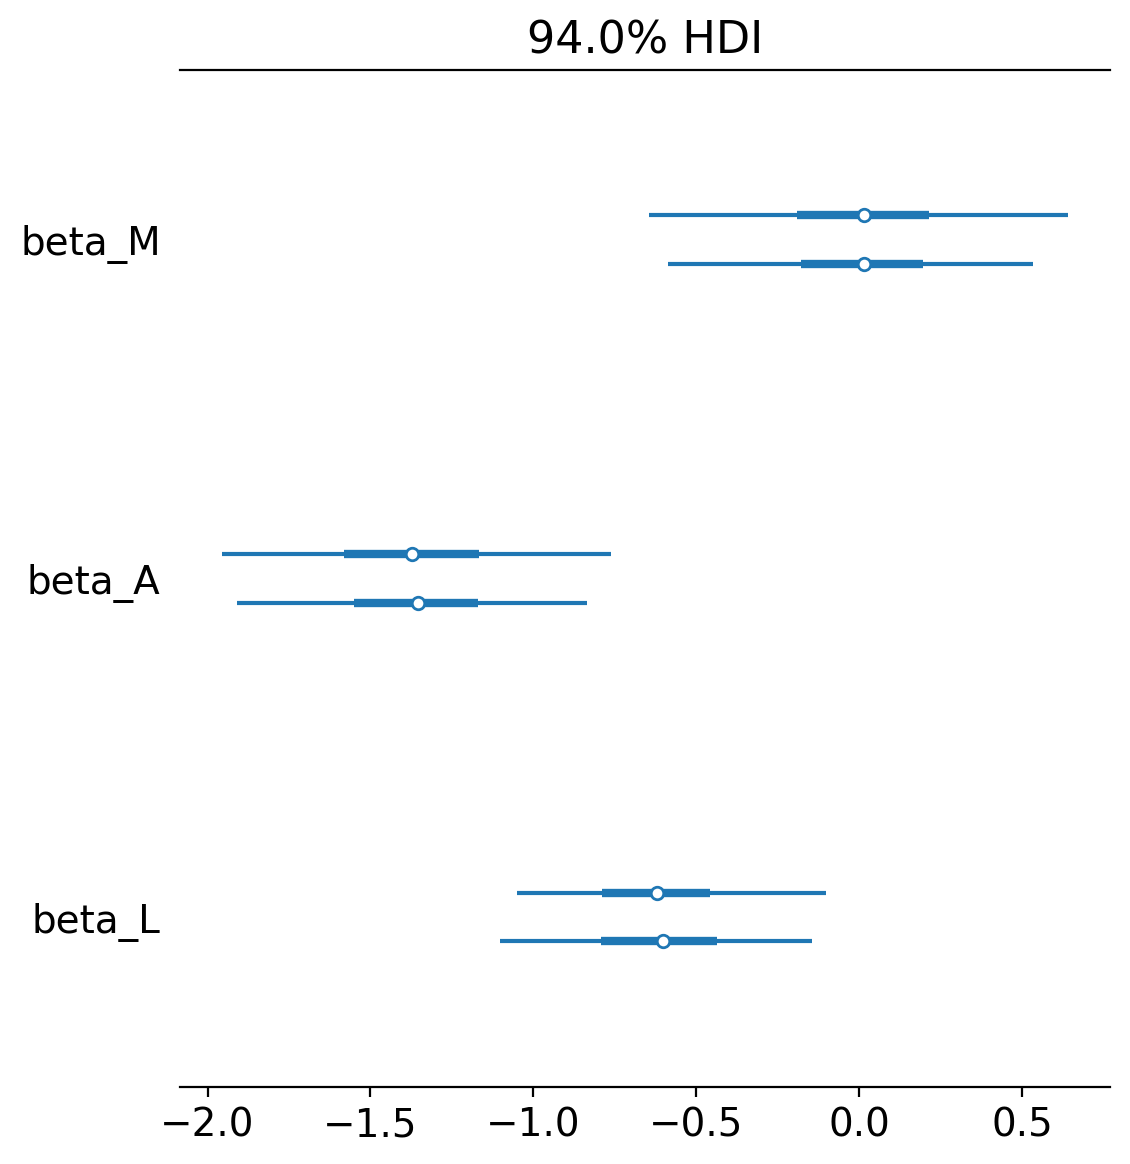

In [7]:
az.plot_forest(samples, var_names=["beta_M", "beta_A", "beta_L"]);

The posterior distribution results support the notion that a higher percentage of LDS followers is generally associated with lower divorce rates. While the marriage rate is not a strong predictor of divorce rates, the median age and the percentage of the LDS population show a strong negative correlation with divorce rates